In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic.vectorizers import ClassTfidfTransformer
from rapidfuzz import fuzz

c:\Users\ASUS\Programmation\lhst-the-ecology-of-eucalyptus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Import bertopic
from bertopic import BERTopic

In [3]:
# Import and filter metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")
df_downloaded = df.dropna(subset="ocr_quality").reset_index()

In [4]:
def import_text(ark, context, size=50, occurrences=False):
    #Keep only paragraphs with "eucalyptus" in them
    if context == "paragraph":
        with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            text = f.readlines()
        #text = [paragraph for paragraph in text if "eucalyp" in paragraph.lower() or "eucalip" in paragraph.lower() or "encalyp" in paragraph.lower()]
        end_text = [paragraph for paragraph in text if fuzz.token_set_ratio("eucalyptus", paragraph.lower()) > 90]

        #merge contexts through "\n" to have a single text
        #TODO: handle better several occurences?
        end_text = "\n".join(end_text)
        return end_text
    
    #Keep only a certain context window around the word "eucalyptus"
    #TODO: check for handling paragraphs
    #TODO: handle better several occurences (what if eucalyptus is in the context of another?)
    elif context == "context_window":
        with open(f"../data/corpus_txt/{ark}.txt", "r", encoding='utf-8') as f:
            #TODO: check if losing "\n" (paragraph) context is important or not
            text = f.read().split()
        
        #separate text into tokens, get a window of {size} in each side of "eucalyptus"
        tokens_context = []
        occurrences = 0
        for i, word in enumerate(text):
            #if "eucalyp" in word.lower() or "eucalip" in word.lower() or "encalyp" in word.lower():
            if fuzz.ratio("eucalyptus", word.lower()) > 75 or "eucalypt" in word.lower() or "encalypt" in word.lower() or "eucalipt" in word.lower():
                new_text = text[i-size:i] + ["eucalyptus"] + text[i+1:i+size]
                tokens_context.append(new_text)
                occurrences += 1


        #merge text within each occurence, then merge paragraphs with "\n"
        end_text = []
        for context in tokens_context:
            end_text.append(" ".join(context))
        end_text = "\n".join(end_text)

        if occurrences:
            return (end_text, occurrences)
        else:
            return end_text

    else:
        raise ValueError('context must be either "paragraph" or "context_window"')

In [5]:
#Import text
print(import_text("bpt6k6148781w", context="context_window"))

("à Tîlè de Madagascar. 1) {V.f. in herb. Lam.) '* MÉTROSIDEROS flexueux. Métrofiderosflexaofia. Willd. Métrofideros foliis alternis , feffilibus, ovato-lanceolatis ; ramis ancipiúbus, flexuofis. Willd. Enum. 1. pag. CI4. Les fleurs-de cétte plante n'ayant pas encore pu être observées, on ignore fi elle appartient plutôt aux métrofideros quaux^melaleuca ou aux eucalyptus Ses tiges s'élèvent en arbre, & font déjà parvenues à la hauteur de dix pieds dans le Jardin des Piantes de Berlin; elles ont parfaitement-le port d'un métrofideros. Les rameaux sont peiîdans ; lés plus jeunes d'un brun-jaunâtre, comprimés, à deux angles; les feuilles alternes, sessiles, longues d'un pouce", 1)


In [6]:
print(import_text("bpt6k6148781w", context="paragraph"))

In [7]:
print(import_text("bpt6k9395289", context="context_window"))

('eucalyptus AIRE GÉOGRAPHIQUE DE LEUR INDIGÉNAT ET I)E LEUR CULTURE HISTORIQUE DE LEUR DÉCOUVERTE DESCRIPTION DE LEURS PROPRIÉTÉS FORESTIÈRES, INDUSTRIELLES, ASSAINISSANTES, MÉDICINALES, ETC. GUIDE THÉORIQUE ET PRATIQUE DE LEUR CULTURE Avec figures intercalées dans le texte et une Carte de la Tasmanie. PAR FÉLIX SAIIUT VICE-PRÉSIDENT DE LA SOCIÉTÉ D’HORTICULTURE\nPRÉSIDENT I)E LA SECTION DE GÉOGRAPHIE PHYSIQUE DE LA SOCIÉTÉ LANGUEDOCIENNE DE GÉOGRAPHIE, ETC., ETC. MONTPELLIER CAMILLE COLLET, LIBRAIRE-ÉDITEUR LIBRAIRE DE La BIBLIOTHÈQUE UNIVERSITAIRE, DE L’ÉCOLE NATIONALE D’AGRICULTURE ET DE L’ACADÉMIE DES SCIENCES ET LETTRES, GRAND’RUE, 5. PARIS A. DELAIIAYE & E. LECROSNIER, LIBRAIRES-ÉDITEURS 23, Place de l’École-de-Médecine. 1888 LES eucalyptus PRINCIPAUX OUVRAGES DU MÊME AUTEUR. 1 0 Les Vigne8 Américaines, leur greffage et leur taille ; élude raisonnée de la possibilité de reconstituer les vignobles et des moyens de défense pour les conserver.— Troisième édition considérablement au

In [8]:
print(import_text("bpt6k5001416j", context="paragraph"))

In [9]:
#import all docs:
all_docs_text = []
all_docs_occurrences = []
for doc in df_downloaded["ark"].to_list():
    text_cleaned = import_text(doc, context="context_window", occurrences=True)
    all_docs_text.append(text_cleaned[0])
    all_docs_occurrences.append(text_cleaned[1])

## 1) Topic modelling

### 1.1) Train the model

In [11]:
#Train model
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
topic_model = BERTopic(ctfidf_model=ctfidf_model, language="multilingual")
topics, probs = topic_model.fit_transform(all_docs_text)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2534.72it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
#Reduce outliers
new_topics = topic_model.reduce_outliers(all_docs_text, topics)

In [13]:
#Assign topics to df:
df_downloaded["topics"] = topics

In [14]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(topic_model.get_topic_info())

     Topic  Count                                            Name  \
0       -1   3423                      -1_essence_été_arbres_leur   
1        0    341                         0_fig_fleurs_plantes_ib   
2        1    203                1_crachats_déc_malade_traitement   
3        2    194                  2_cimetière_ville_mer_palmiers   
4        3    108                          3_tu_dathol_vous_comaz   
5        4    106                4_mètres_pieds_californie_géants   
6        5    101                       5_livrables_05_tentes_pag   
7        6    101          6_australie_flore_protéacées_continent   
8        7     99                   7_hectares_écuries_louée_sise   
9        8     89         8_ombrager_habitées_algérie_plantations   
10       9     70                       9_espèces_tasmanie_ve_mèt   
11      10     69                         10_roma_dell_malaria_di   
12      11     68   11_fianarantsoa_district_consistant_propriété   
13      12     68                 

In [15]:
topic_document_info_df = topic_model.get_document_info(all_docs_text)
topic_document_info_df[topic_document_info_df["Representative_document"] == True]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
4,que Ga:rthër avoit. employé pour former un gen...,5,5_livrables_05_tentes_pag,"[livrables, 05, tentes, pag, operculo, smith, ...","[des pl, IX, 40.) HARissoNA (LÉMAN). Pour Harr...",livrables - 05 - tentes - pag - operculo - smi...,0.279858,True
13,fable plus ou moins élevées ; la roche qui les...,24,24_meth_brid_schw_dunes,"[meth, brid, schw, dunes, plaines, roches, roc...",[les rives étaient à peu près dénudées et frus...,meth - brid - schw - dunes - plaines - roches ...,0.999317,True
28,"tombe comme celles de nos platanes, se détache...",0,0_fig_fleurs_plantes_ib,"[fig, fleurs, plantes, ib, genre, feuilles, ho...","[tombe comme celles de nos platanes, se détach...",fig - fleurs - plantes - ib - genre - feuilles...,0.929687,True
46,"les Rotangs, palmiers des régions tropicales d...",4,4_mètres_pieds_californie_géants,"[mètres, pieds, californie, géants, diamètre, ...",[vulgarisation qui ne contiendrait pas un chap...,mètres - pieds - californie - géants - diamètr...,1.000000,True
58,in-8. Auteur. Charles Courret. — A l’est et à ...,75,75_marine_notice_intercalée_organogénie,"[marine, notice, intercalée, organogénie, lein...","[Giessen, i853; in-8°. Atmosphàrischer. Sur la...",marine - notice - intercalée - organogénie - l...,1.000000,True
...,...,...,...,...,...,...,...,...
7232,possession lui permettra de se faire reconnaît...,19,19_martial_durand_hier_nommé,"[martial, durand, hier, nommé, crime, somberno...",[possession lui permettra de se faire reconnaî...,martial - durand - hier - nommé - crime - somb...,0.683612,True
7340,"de Pâques, à l'hôtel de ville de Troyes. On y ...",48,48_miel_abeilles_ruches_peronnet,"[miel, abeilles, ruches, peronnet, pinon, miel...","[de Pâques, à l'hôtel de ville de Troyes. On y...",miel - abeilles - ruches - peronnet - pinon - ...,0.412090,True
7354,"Septoria albo punctata, Gke. 623 S. ampelina, ...",83,83_th_eucalypti_tit_cinéol,"[th, eucalypti, tit, cinéol, nssl, chriodora, ...","[570 — Jekeli, 1882, 570 (COL.) Abax caledonic...",th - eucalypti - tit - cinéol - nssl - chriodo...,0.802792,True
7375,(L'article 1er est mis aux voix et adopté.) « ...,14,14_dépense_projet_travaux_calvi,"[dépense, projet, travaux, calvi, montant, min...",[(L'article 1er est mis aux voix et adopté.) «...,dépense - projet - travaux - calvi - montant -...,1.000000,True


### 1.2) Model Analysis

In [16]:
pd.set_option('display.max_columns', 121)
cross_tab = pd.crosstab(df_downloaded.type_clean, df_downloaded.topics)
cross_tab

topics,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105
type_clean,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
annuaire,44,3,2,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,2,1,0,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,6,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,1,0,0,0,0,1,0,0,0,0,0
monographie,912,149,81,60,19,43,55,65,3,24,19,29,0,0,9,2,24,2,2,37,2,18,2,6,19,17,17,1,1,3,1,11,20,1,0,3,0,4,5,1,0,19,9,10,0,3,4,20,0,11,6,11,1,9,9,4,0,0,2,1,5,1,2,1,4,0,14,2,0,8,20,1,1,1,3,0,0,1,7,6,6,1,0,0,9,5,0,2,6,6,2,0,5,4,0,0,2,0,4,1,3,3,3,5,0,0,2
presse généraliste,1595,72,34,113,84,39,10,13,82,49,29,23,0,66,41,26,21,0,32,4,49,12,36,15,7,11,11,36,33,17,36,5,0,33,36,32,2,12,23,5,30,0,11,14,24,11,23,2,23,7,13,12,19,14,2,12,20,1,14,19,15,0,18,9,16,16,2,18,17,10,0,14,17,15,11,17,4,16,6,8,2,15,15,15,0,5,13,7,8,3,9,13,6,2,11,2,3,12,6,5,6,5,5,3,9,1,8
presse officielle,210,20,4,1,0,2,11,2,10,2,1,5,67,2,6,26,1,0,2,0,0,7,0,2,2,1,1,0,1,15,1,13,0,0,0,0,32,12,0,2,0,0,1,0,2,3,1,0,2,1,0,1,4,2,1,0,1,21,0,1,1,20,0,7,0,0,0,0,2,0,0,3,0,1,2,1,1,0,1,0,1,0,0,0,0,1,0,2,0,3,0,0,0,5,1,9,6,0,1,5,3,0,3,2,1,0,0
presse spécialisée,662,97,82,20,5,21,25,21,3,14,21,12,0,0,8,6,13,56,22,15,4,12,6,19,13,11,9,1,3,3,0,9,16,1,0,0,0,4,2,22,0,11,9,5,2,9,0,5,0,7,6,1,1,0,12,7,2,1,1,1,1,0,1,4,1,4,4,0,1,1,0,0,1,2,3,0,7,1,2,2,5,0,1,0,6,4,1,3,0,2,2,0,2,2,0,0,1,0,1,1,0,3,1,1,1,9,0


In [86]:
topic_number = 4
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 4


[('mètres', np.float64(0.2521404557616658)),
 ('pieds', np.float64(0.2287724152090281)),
 ('californie', np.float64(0.20651271802125573)),
 ('géants', np.float64(0.20500581020422337)),
 ('diamètre', np.float64(0.19155360379393258)),
 ('hauteur', np.float64(0.19068501869894264)),
 ('mount', np.float64(0.18924394112846085)),
 ('séquoia', np.float64(0.18032936372648642)),
 ('dandenong', np.float64(0.17559568283586477)),
 ('séquoias', np.float64(0.17287736270198342))]

In [87]:
topic_model.visualize_topics()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'fig | fleurs | plantes | ib | genre', 341],
                                   [1, 'crachats | déc | malade | traitement | injections', 203],
                                   [2, 'cimetière | ville | mer | palmiers | soleil', 194],
                                   ...,
                                   [103, '301 | fouch1er | droits | eulalie | gapeau', 11],
                                   [104,
                                    'cristallisé | anthoine | intervalle | représente | inconvénients',
                                    10],
                                   [105, 'nouillettes | lucullus | butaient | soucier | alyscamps', 10]],
                                  shape=(106, 3), dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': ('VQHLAMIAbABqAGUAZQBjAFkARgBFAE' ... '0ADAAMAAwADAAMAAwACwALAAoACgA='),
                                  'dtype': 'i2'},
                         'sizemode': 'area',
                         'sizeref': 0.213125,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('sF8nQCNWSEFIdo5A3K+CQc97Kj46U5' ... 'Dhn++87TfUPsXGUkEYRlFBcPvbwA=='),
                    'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': ('PYwCQcJ9osDQ02lAJulrQFckAUHCq1' ... '/KEvRA3Aj3QK4rKUHAhKXALVWfQQ=='),
                    'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-13.763651),
                                'y': np.float32(7.3931446),
                                'yshift': 10},
                               {'showarrow': False,
                                'text': 'D2',
                                'x': np.float32(2.6257305),
                                'xshift': 10,
                                'y': np.float32(22.904078)}],
               'height': 650,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'margin': {'t': 60},
               'shapes': [{'line': {'color': '#CFD8DC', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(2.6257305),
                           'x1': np.float32(2.6257305),
                           'y0': np.float32(-8.117788),
                           'y1': np.float32(22.904078)},
                          {'line': {'color': '#9E9E9E', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-13.763651),
                           'x1': np.float32(19.015112),
                           'y0': np.float32(7.3931446),
                           'y1': np.float32(7.3931446)}],
               'sliders': [{'active': 0,
                            'pad': {'t': 50},
                            'steps': [{'args': [{'marker.color': [['red',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                           

## 2) Occurences

In [24]:
df_downloaded["occurences"] = all_docs_occurrences

In [63]:
df_downloaded.groupby("type_clean")["occurences"].describe()

,count,mean,std,min,25%,50%,75%,max
type_clean,,,,,,,,
annuaire,82.0,4.890244,14.099300,1.0,1.0,1.0,3.0,113.0
monographie,1932.0,5.474120,19.750748,1.0,1.0,2.0,4.0,506.0
presse généraliste,3433.0,2.027381,3.965962,1.0,1.0,1.0,2.0,138.0
presse officielle,584.0,2.256849,2.634861,1.0,1.0,1.0,2.0,21.0
presse spécialisée,1399.0,6.474625,22.440875,1.0,1.0,2.0,4.0,450.0


In [72]:
df_downloaded.sort_values(by="occurences", ascending=False)[["occurences", "title_clean", "date_clean", "author_name_clean", "type_clean", "topics"]].head(15)

,occurences,title_clean,date_clean,author_name_clean,type_clean,topics
502,506,"Les eucalyptus, aire géographique de leur indi...",1888.0,"Sahut, Félix",monographie,9
936,450,Bulletin de la Société d'acclimatation,1872.0,Société nationale de protection de la nature (...,presse spécialisée,-1
1542,400,L'eucalyptus et ses dérivés,1898.0,"Combes, Paul",monographie,44
1191,320,Bulletin de la Société d'acclimatation,1873.0,Société nationale de protection de la nature (...,presse spécialisée,-1
1716,289,L'eucalyptus,1875.0,"Raveret-Wattel, Casimir",monographie,-1
5233,275,La Médecine moderne,1894.0,NaN,presse spécialisée,17
2691,266,L'eucalyptus et ses applications industrielles,1877.0,"Martin, Félix (ingénieur des Ponts et chaussées)",monographie,44
1700,218,Assainissement des régions chaudes insalubres,1875.0,"Carlotti, Antoine-Louis-Régulus",monographie,100
446,213,Lyon médical,1887.0,Société médicale des hôpitaux de Lyon,presse spécialisée,1
290,195,Bulletin,1886.0,Société languedocienne de géographie,presse spécialisée,-1


## 3) Distributions

<Axes: xlabel='date_clean', ylabel='Density'>

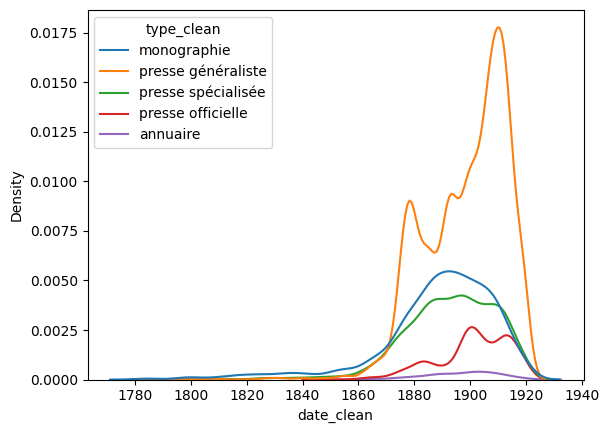

In [20]:
sns.kdeplot(df, x="date_clean", hue="type_clean")

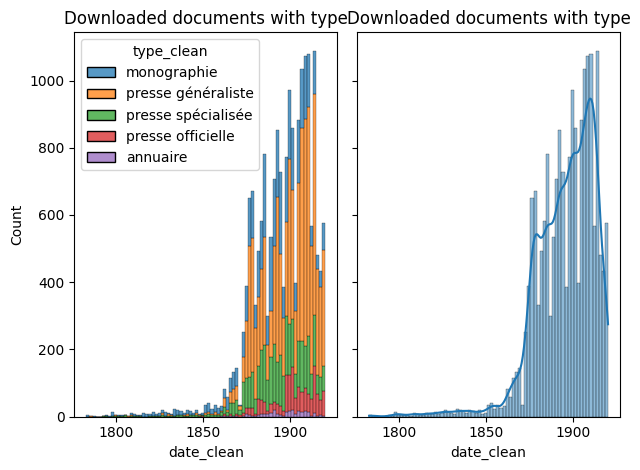

In [21]:
fig, ax = plt.subplots(1, 2, sharey=True)
plt.sca(ax[0])
plt.title("Downloaded documents with type")
sns.histplot(df, x="date_clean", hue="type_clean", multiple="stack")
plt.sca(ax[1])
plt.title("Downloaded documents with type")
sns.histplot(df, x="date_clean", kde=True)
plt.tight_layout()
plt.show()

In [22]:
df["type_clean"].value_counts()

type_clean
presse généraliste    9515
monographie           4419
presse spécialisée    3467
presse officielle     1369
annuaire               239
Name: count, dtype: int64